In [1]:
!pip install av

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.8/33.8 MB 42.8 MB/s eta 0:00:00


In [2]:
import torch
from transformers import VideoMAEForVideoClassification, VideoMAEImageProcessor
from torch.utils.data import DataLoader, Dataset
import torch.optim as optim
from torchvision.io import read_video
from PIL import Image
from torchvision import transforms

model = VideoMAEForVideoClassification.from_pretrained("MCG-NJU/videomae-base", num_labels=28)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

processor = VideoMAEImageProcessor.from_pretrained("MCG-NJU/videomae-base")

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/725 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/377M [00:00<?, ?B/s]

Some weights of VideoMAEForVideoClassification were not initialized from the model checkpoint at MCG-NJU/videomae-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


preprocessor_config.json:   0%|          | 0.00/271 [00:00<?, ?B/s]

In [3]:
import os
from sklearn.model_selection import train_test_split

class VideoDataset(Dataset):
    def __init__(self, video_paths, labels, processor, num_frames=16, transforms=None):
        self.video_paths = video_paths
        self.labels = labels
        self.processor = processor
        self.num_frames = num_frames
        self.transforms = transforms

    def __len__(self):
        return len(self.video_paths)

    def __getitem__(self, idx):
        video_path = self.video_paths[idx]
        label = self.labels[idx]

        video, _, _ = read_video(video_path, pts_unit='sec')
        step = max(1, video.shape[0] // self.num_frames)
        frames = [frame.numpy() for frame in video[::step][:self.num_frames]]

        pil_frames = [Image.fromarray(frame.astype(np.uint8)) for frame in frames]

        if self.transforms:
            pil_frames = [self.transforms(frame) for frame in pil_frames]

        inputs = self.processor(images=pil_frames, return_tensors="pt")

        inputs['labels'] = torch.tensor(label, dtype=torch.long)

        return inputs


def get_video_paths_and_labels(root_dir):
    video_paths = []
    labels = []

    for label, class_folder in enumerate(sorted(os.listdir(root_dir))):
        class_path = os.path.join(root_dir, class_folder)

        if os.path.isdir(class_path):
            for video_file in sorted(os.listdir(class_path)):
                video_path = os.path.join(class_path, video_file)
                if video_path.endswith(('.mp4', '.avi', '.mov')):
                    video_paths.append(video_path)
                    labels.append(label)

    return video_paths, labels

root_dir = "/content/drive/MyDrive/Colab Notebooks/data"
video_paths, labels = get_video_paths_and_labels(root_dir)

train_video_paths, test_video_paths, train_labels, test_labels = train_test_split(video_paths, labels, test_size=0.2, random_state=101)

train_dataset = VideoDataset(train_video_paths, train_labels, processor, num_frames=16)
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, num_workers=0)

test_dataset = VideoDataset(test_video_paths, test_labels, processor, num_frames=16)
test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False, num_workers=0)

In [4]:
print(f"Labels range min={min(labels)}, max={max(labels)}")

Labels range min=0, max=27


In [5]:
import numpy as np
import torch
import time

criterion = torch.nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-4)


epochs = 10
for epoch in range(epochs):
    model.train()
    start_time = time.time()
    running_loss = 0.0
    correct = 0
    total = 0

    for batch in train_loader:
        inputs = {key: value.squeeze().to(device) for key, value in batch.items()}
        labels = inputs.pop('labels')

        optimizer.zero_grad()

        outputs = model(**inputs)
        logits = outputs.logits

        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(logits, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    accuracy = (correct / total) * 100
    average_loss = running_loss / len(train_loader)
    end_time = time.time()
    total_time = (end_time - start_time) / 60
    print(f"Epoch {epoch+1}/{epochs}, Accuracy: {accuracy:.2f}%, , Loss: {average_loss:.4f}, Total Time: {total_time:.4f}")

Epoch 1/10, Accuracy: 1.87%, , Loss: 3.4301, Total Time: 27.2021
Epoch 2/10, Accuracy: 3.31%, , Loss: 3.3499, Total Time: 9.6268
Epoch 3/10, Accuracy: 5.33%, , Loss: 3.2895, Total Time: 9.6209
Epoch 4/10, Accuracy: 7.06%, , Loss: 3.2078, Total Time: 9.6387
Epoch 5/10, Accuracy: 10.09%, , Loss: 3.0738, Total Time: 9.6406
Epoch 6/10, Accuracy: 12.82%, , Loss: 2.8829, Total Time: 9.6050
Epoch 7/10, Accuracy: 20.03%, , Loss: 2.5656, Total Time: 9.6288
Epoch 8/10, Accuracy: 25.50%, , Loss: 2.2568, Total Time: 9.6502
Epoch 9/10, Accuracy: 40.49%, , Loss: 1.8746, Total Time: 9.6314
Epoch 10/10, Accuracy: 46.69%, , Loss: 1.6360, Total Time: 9.6272


In [6]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

model.eval()
correct = 0
total = 0
running_loss = 0.0
criterion = torch.nn.CrossEntropyLoss()

y_true = []
y_pred = []

with torch.no_grad():
    start_time = time.time()

    for batch in test_loader:
        inputs = {key: value.squeeze().to(device) for key, value in batch.items()}
        labels = inputs.pop('labels')

        outputs = model(**inputs)
        logits = outputs.logits

        loss = criterion(logits, labels)
        running_loss += loss.item()

        _, predicted = torch.max(logits, 1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    accuracy = (correct / total) * 100
    end_time = time.time()
    total_time = (end_time - start_time) / 60

    print(f"Test Accuracy: {accuracy:.2f}%")
    print(f"Average Loss: {running_loss / len(test_loader):.4f}")
    print(f"Total Time for Testing: {total_time:.2f} minutes")

Test Accuracy: 10.92%
Average Loss: 3.4230
Total Time for Testing: 6.44 minutes


In [7]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)
print("\nClassification Report:")
print(classification_report(y_true, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.10      0.17      0.12         6
           1       0.00      0.00      0.00         6
           2       0.07      0.25      0.11         4
           3       0.00      0.00      0.00         8
           4       1.00      0.10      0.18        10
           5       0.00      0.00      0.00         8
           6       0.11      0.12      0.12         8
           7       0.25      0.50      0.33         6
           8       0.25      0.25      0.25         4
           9       0.00      0.00      0.00         8
          10       0.00      0.00      0.00         9
          11       0.00      0.00      0.00         6
          12       0.20      0.20      0.20         5
          13       0.00      0.00      0.00         5
          14       0.00      0.00      0.00         9
          15       0.00      0.00      0.00         4
          16       0.00      0.00      0.00         5
   

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


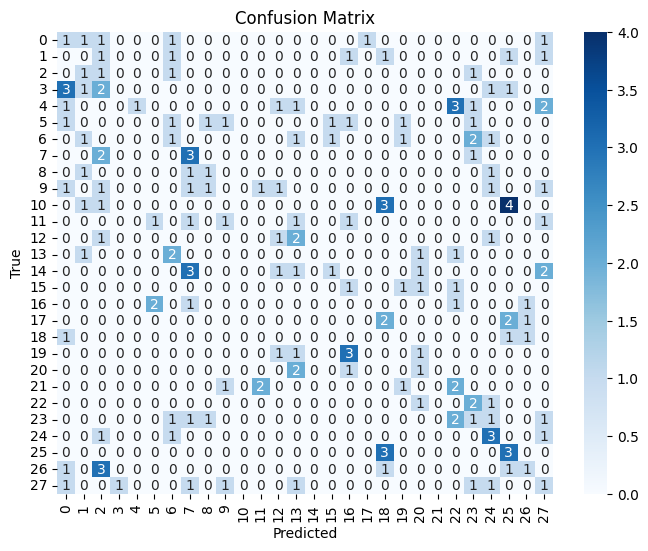

In [8]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=np.unique(y_true), yticklabels=np.unique(y_true))
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [9]:
from google.colab import files

torch.save(model.state_dict(), "Epoch_20.pth")
files.download("Epoch_20.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>